In [1]:
import pandas as pd
import py3Dmol
from rdkit import Chem 
from rdkit.Chem import AllChem
from rism_scf import RISM_SCF
import openmm as mm 
from openff.toolkit.topology import Molecule, Topology
import numpy as np
from MDAnalysis.transformations import center_in_box
from episol import epipy
import matplotlib.pyplot as plt

All Checks complete
Good to go!


/Users/khangluong/miniconda3/envs/dft-rism-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv("SAMPL.csv") # expt energy in kcal/mol and calc in kcal/mol
display(data.head())

,iupac,smiles,expt,calc
0,"4-methoxy-N,N-dimethyl-benzamide",CN(C)C(=O)c1ccc(cc1)OC,-11.01,-9.625
1,methanesulfonyl chloride,CS(=O)(=O)Cl,-4.87,-6.219
2,3-methylbut-1-ene,CC(C)C=C,1.83,2.452
3,2-ethylpyrazine,CCc1cnccn1,-5.45,-5.809
4,heptan-1-ol,CCCCCCCO,-4.21,-2.917


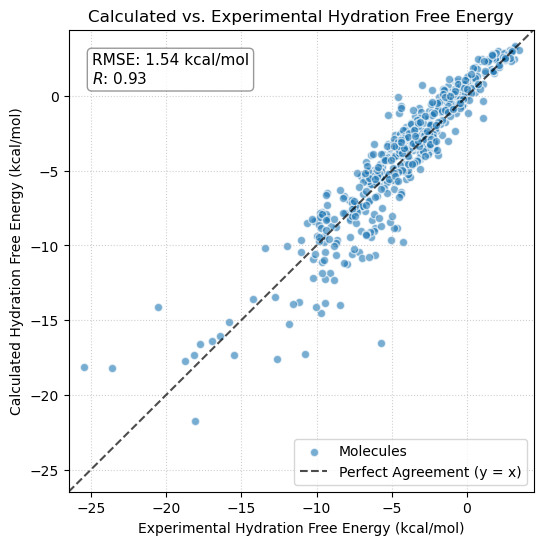

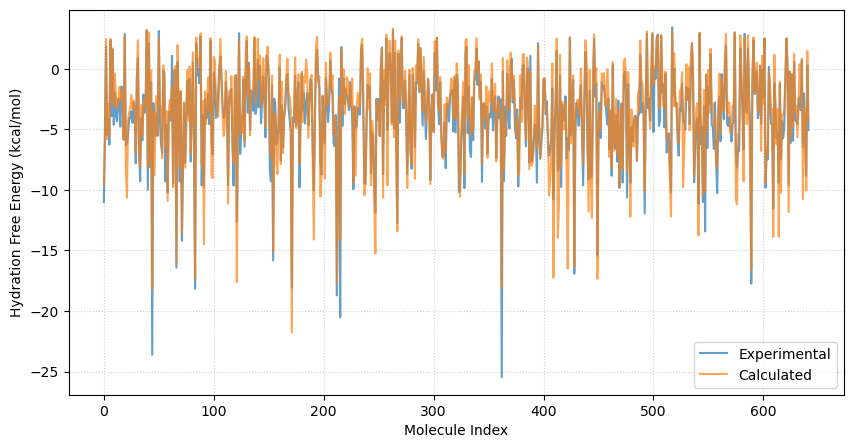

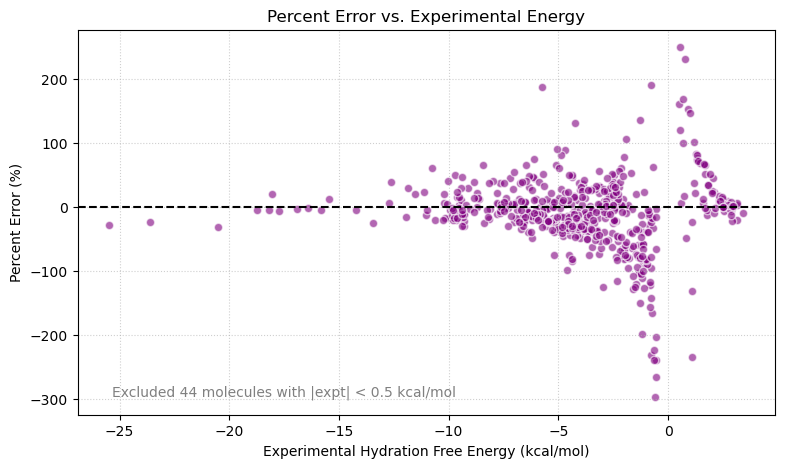

In [3]:
plt.figure(figsize=(6, 6))

plt.scatter(data['expt'], data['calc'], alpha=0.6, edgecolors='w', label='Molecules', color='#1f77b4')

min_val = min(data['expt'].min(), data['calc'].min()) - 1
max_val = max(data['expt'].max(), data['calc'].max()) + 1
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, label='Perfect Agreement (y = x)')

rmse = np.sqrt(np.mean((data['calc'] - data['expt'])**2))
r = np.corrcoef(data['expt'], data['calc'])[0, 1]

plt.text(0.05, 0.95, f'RMSE: {rmse:.2f} kcal/mol\n$R$: {r:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.xlabel('Experimental Hydration Free Energy (kcal/mol)')
plt.ylabel('Calculated Hydration Free Energy (kcal/mol)')
plt.title('Calculated vs. Experimental Hydration Free Energy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(data.index, data['expt'], label='Experimental', alpha=0.7)
plt.plot(data.index, data['calc'], label='Calculated', alpha=0.7)
plt.xlabel('Molecule Index')
plt.ylabel('Hydration Free Energy (kcal/mol)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

threshold = 0.5  # kcal/mol
filtered_data = data[data['expt'].abs() > threshold].copy()

filtered_data['pct_error'] = ((filtered_data['calc'] - filtered_data['expt']) / filtered_data['expt']) * 100

plt.figure(figsize=(9, 5))
plt.scatter(filtered_data['expt'], filtered_data['pct_error'], alpha=0.6, color='purple', edgecolors='w')
plt.axhline(0, color='black', linestyle='--')

num_excluded = len(data) - len(filtered_data)
plt.text(0.05, 0.05, f'Excluded {num_excluded} molecules with |expt| < {threshold} kcal/mol',
         transform=plt.gca().transAxes, fontsize=10, color='gray')

plt.xlabel('Experimental Hydration Free Energy (kcal/mol)')
plt.ylabel('Percent Error (%)')
plt.title('Percent Error vs. Experimental Energy')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


Calculating RISM-SCF:   0%|          | 0/10 [00:00<?, ?it/s]/Users/khangluong/miniconda3/envs/dft-rism-env/lib/python3.11/site-packages/openff/interchange/components/interchange.py:1119: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if isinstance(obj, functools._lru_cache_wrapper) and obj.__module__.startswith("openff.interchange"):
/Users/khangluong/miniconda3/envs/dft-rism-env/lib/python3.11/site-packages/MDAnalysis/coordinates/GRO.py:444: UserWarning: Supplied AtomGroup was missing the following attributes: resnames. These will be written with default values. Alternatively these can be supplied as keyword arguments.
  warnings.warn(


converged SCF energy = -593.354689209686
molecules


Overwritten attributes  energy_nuc get_hcore  of <class 'pyscf.dft.rks.RKS'>


Overwritten attributes  energy_nuc get_hcore  of <class 'pyscf.dft.rks.RKS'>
converged SCF energy = -593.066006927977
converged SCF energy = -592.91666191791
converged SCF energy = -592.748018096102


Calculating RISM-SCF:  10%|█         | 1/10 [05:43<51:27, 343.03s/it]/Users/khangluong/miniconda3/envs/dft-rism-env/lib/python3.11/site-packages/openff/interchange/components/interchange.py:1119: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if isinstance(obj, functools._lru_cache_wrapper) and obj.__module__.startswith("openff.interchange"):


...

[9/10] Success: 1,2-dimethylcyclohexane | dG = 13.03 kcal/mol


/Users/khangluong/miniconda3/envs/dft-rism-env/lib/python3.11/site-packages/MDAnalysis/coordinates/GRO.py:444: UserWarning: Supplied AtomGroup was missing the following attributes: resnames. These will be written with default values. Alternatively these can be supplied as keyword arguments.
  warnings.warn(


converged SCF energy = -233.375312553879
molecules
converged SCF energy = -233.572766455156
converged SCF energy = -233.974254538242
converged SCF energy = -234.145353650011


Calculating RISM-SCF: 100%|██████████| 10/10 [35:08<00:00, 210.88s/it]

[10/10] Success: butan-2-ol | dG = -14.73 kcal/mol


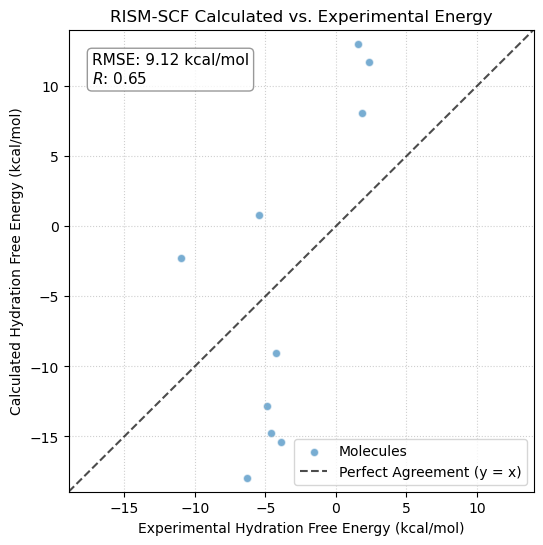

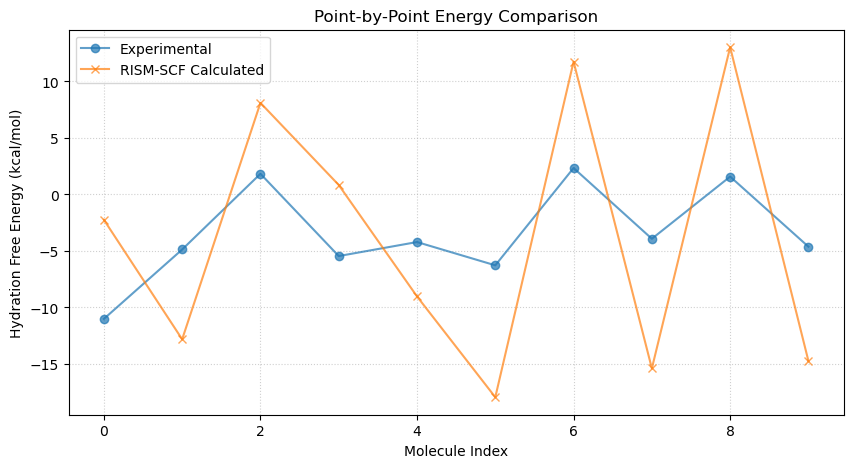

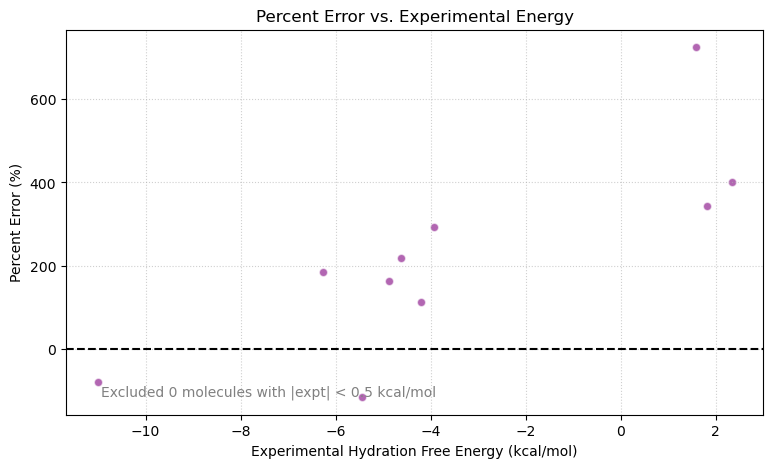

In [4]:
import os
import sys
from contextlib import contextmanager
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from rdkit import Chem
from rdkit.Chem import AllChem
from openff.toolkit.topology import Molecule, Topology
from openff.toolkit.typing.engines.smirnoff import ForceField
from openff.interchange import Interchange
import MDAnalysis as md
from MDAnalysis.transformations import center_in_box
from rism_scf import RISM_SCF

# Helper to suppress PySCF and EPISOL logs from bloating the notebook
@contextmanager
def silence_stdout():
    new_target = open(os.devnull, "w")
    old_target = sys.stdout
    sys.stdout = new_target
    try:
        yield new_target
    finally:
        sys.stdout = old_target
        new_target.close()

# Limit calculation to the first 10 molecules
num_molecules = 10
data_subset = data.head(num_molecules).copy()

rism_scf_calc = []

# Loop with tqdm progress bar
for i in tqdm(range(num_molecules), desc="Calculating RISM-SCF"):
    iupac_name = data_subset['iupac'].iloc[i]
    smiles_string = data_subset['smiles'].iloc[i]
    
    try:
        # Generate 3D coordinates (Conformer)
        mol = Chem.MolFromSmiles(smiles_string)
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol, randomSeed=42)
        AllChem.MMFFOptimizeMolecule(mol)
        
        # Build OpenFF & MDAnalysis structures
        molecule = Molecule(mol)
        topology = molecule.to_topology()
        sage = ForceField("openff-2.0.0.offxml")
        interchange = Interchange.from_smirnoff(force_field=sage, topology=topology)
        interchange.positions = molecule.conformers[0]
        openmm_system = interchange.to_openmm()
        interchange.to_top("out.top")
        
        nn = md.Universe(mol)
        nn.dimensions = np.array([30, 30, 30, 90, 90, 90])
        tt = center_in_box(nn.atoms, center='geometry')
        nn.trajectory.add_transformations(tt)
        nn.atoms.write('out.gro')
        
        # Run calculation inside the silencer
        solver = RISM_SCF(solute_geometry=mol, gro_path="out.gro", top_path="out.top", scheme="esp", max_cycles=3)
        with silence_stdout():
            solver.run()
        
        # Convert net solvation free energy from Hartree to kcal/mol
        dG_solv_kcal = solver.dG_solv * 627.509
        rism_scf_calc.append(dG_solv_kcal)
        
        # Clean progress updates
        tqdm.write(f"[{i+1}/{num_molecules}] Success: {iupac_name} | dG = {dG_solv_kcal:.2f} kcal/mol")
        
    except Exception as e:
        tqdm.write(f"[{i+1}/{num_molecules}] Failed: {iupac_name} | Error: {e}")
        rism_scf_calc.append(np.nan)
        
    # Clean up temporary files for this iteration
    for f_path in ["out.gro", "out.top"]:
        if os.path.exists(f_path):
            try:
                os.remove(f_path)
            except OSError:
                pass

# Add results to our subset dataframe
data_subset['rism_scf_calc'] = rism_scf_calc

# Drop any molecules where calculations failed (NaNs) to clean up plots
data_plot = data_subset.dropna(subset=['rism_scf_calc']).copy()

# ================= PLOT 1: Parity Plot =================
plt.figure(figsize=(6, 6))
plt.scatter(data_plot['expt'], data_plot['rism_scf_calc'], alpha=0.6, edgecolors='w', label='Molecules', color='#1f77b4')

min_val = min(data_plot['expt'].min(), data_plot['rism_scf_calc'].min()) - 1
max_val = max(data_plot['expt'].max(), data_plot['rism_scf_calc'].max()) + 1
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, label='Perfect Agreement (y = x)')

rmse = np.sqrt(np.mean((data_plot['rism_scf_calc'] - data_plot['expt'])**2))
r = np.corrcoef(data_plot['expt'], data_plot['rism_scf_calc'])[0, 1]

plt.text(0.05, 0.95, f'RMSE: {rmse:.2f} kcal/mol\n$R$: {r:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.xlabel('Experimental Hydration Free Energy (kcal/mol)')
plt.ylabel('Calculated Hydration Free Energy (kcal/mol)')
plt.title('RISM-SCF Calculated vs. Experimental Energy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ================= PLOT 2: Index Comparison Plot =================
plt.figure(figsize=(10, 5))
plt.plot(data_plot.index, data_plot['expt'], label='Experimental', alpha=0.7, marker='o')
plt.plot(data_plot.index, data_plot['rism_scf_calc'], label='RISM-SCF Calculated', alpha=0.7, marker='x')
plt.xlabel('Molecule Index')
plt.ylabel('Hydration Free Energy (kcal/mol)')
plt.title('Point-by-Point Energy Comparison')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ================= PLOT 3: Percent Error Plot =================
threshold = 0.5  # kcal/mol
filtered_data = data_plot[data_plot['expt'].abs() > threshold].copy()

filtered_data['pct_error'] = ((filtered_data['rism_scf_calc'] - filtered_data['expt']) / filtered_data['expt']) * 100

plt.figure(figsize=(9, 5))
plt.scatter(filtered_data['expt'], filtered_data['pct_error'], alpha=0.6, color='purple', edgecolors='w')
plt.axhline(0, color='black', linestyle='--')

num_excluded = len(data_plot) - len(filtered_data)
plt.text(0.05, 0.05, f'Excluded {num_excluded} molecules with |expt| < {threshold} kcal/mol',
         transform=plt.gca().transAxes, fontsize=10, color='gray')

plt.xlabel('Experimental Hydration Free Energy (kcal/mol)')
plt.ylabel('Percent Error (%)')
plt.title('Percent Error vs. Experimental Energy')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
